In [2]:
%load_ext autoreload
%autoreload 2

import random
import pickle
import json

import pandas as pd
pd.options.display.max_columns = 100

# Подргужаем модули
import all_blocks
from merge_contracts import ContractsMerger
from generate_test import generate_preds
from get_distribution_utils import get_disrib_sums, cost_columns_to_datetime
from forecasting import load_data, make_predict_timeseries

c:\users\никита\appdata\local\programs\python\python39\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Подгружаем и обрабатываем входные данные

In [3]:
pays_df1 = pd.read_excel("data/Счета на оплату 3800-2023.XLSX")
pays_df2 = pd.read_excel("data/Счета на оплату 4200-4000-3800-2024.XLSX")
pays_df3 = pd.read_excel("data/Счета на оплату 5400-2023.XLSX")
pays_df4 = pd.read_excel("data/Счета на оплату 5400-2024.XLSX")
pays_df5 = pd.read_excel("data/Счета на оплату 5500-2023.XLSX")

In [4]:
pays_df = pd.concat([pays_df1, pays_df2, pays_df3, pays_df4, pays_df5], axis=0)

In [5]:
merger_df = pd.read_excel("data/Связь договор - здания.XLSX")
main_costs_df = pd.read_excel("data/Основные средства.XLSX")
squares = pd.read_excel("data/Площади зданий.XLSX")
serv_codes = pd.read_excel("data/Коды услуг.XLSX")

In [6]:
# добавляем фичи чтобы показать что система поддерживает новые драйверы
# в случае их появления в исходной таблице
main_costs_df["тест_фича_нум"] = [random.randint(0, 100) for i in range(len(main_costs_df))]
main_costs_df["тест_фича_бул"] = [random.randint(0, 1) for i in range(len(main_costs_df))]
main_costs_df["тест_фича_дата"] = ["19.04.2006"] * len(main_costs_df)

In [6]:
merger = ContractsMerger(pays_df, merger_df, main_costs_df, squares, serv_codes)

E:\DIR_python_projects\ledaer_digital_transformation_24\zakupai\services\api\ml\lib\merge_contracts.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.needed_pays_df["time"] = self.needed_pays_df["Год"].map(lambda x: datetime(year=x, month=1, day=1))


In [7]:
import time

t = time.time()
res, features = merger.start_merging()
print(time.time() - t)

81.13339138031006


In [10]:
# сохраняем результат с 1 страницы загрузки данных
res.to_csv("res_datetimes.csv")
with open("features.pkl", "wb") as f:
    pickle.dump(features, f)

## Подгружаем граф, запускаем распределение

In [11]:
features = pickle.load(open("features.pkl", "rb"))
res = pd.read_csv("res_datetimes.csv", index_col=0)

C:\Users\843E~1\AppData\Local\Temp/ipykernel_18224/930177580.py:2: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  res = pd.read_csv("res_datetimes.csv", index_col=0)


In [12]:
numeric_features = [i[0] for i in features if i[2] != "date"]
date_features = [i[0] for i in features if i[2] == "date"]

res = cost_columns_to_datetime(res, date_features)

In [69]:
res_by_prime = res.groupby("prime")
raw_graph = json.load(open("graphs/graph (6).json", "r"))

In [101]:
all_blocks.init_graph(raw_graph, features)

In [121]:
unique_primes = res["prime"].unique()
distrib_sums = get_disrib_sums(res_by_prime, res["prime"].unique(), numeric_features)

100%|██████████| 4793/4793 [00:10<00:00, 449.76it/s]


In [122]:
preds = generate_preds(pays_df, serv_codes, res, distrib_sums)

100%|██████████| 4793/4793 [00:09<00:00, 507.11it/s]


In [244]:
preds.to_csv("Результат_распределенные_счета.csv")  # мы получили готовое распределени

In [177]:
# посмотрим на результат
# также предсказан счет главной книги
preds.head(20)

,Компания,Год счета,Номер счета,Позиция счета,Номер позиции распределения,Дата отражения в учетной системе,ID договора,Услуга,Класс услуги,Здание,Класс ОС,ID основного средства,"Признак ""Использование в основной деятельности""","Признак ""Способ использования""",Площадь ОС,Сумма распределения,Счет главной книги,ID услуги
0,3800,2023,5006170938,1,0,2023-01-16,ДПН 3800/74661,800003299,S001,ЗДН 3800/1/265,60401018,38006040010385571,1,1,1.00,540679.38,7048208010,S001
1,3800,2023,5006170938,1,1,2023-01-16,ДПН 3800/74661,800003299,S001,ЗДН 3800/1/265,60401018,38006040010385572,0,1,1.10,594747.32,7048208010,S001
2,3800,2023,5006170938,1,2,2023-01-16,ДПН 3800/74661,800003299,S001,ЗДН 3800/1/1538,60804001,38006080400345271,0,0,0.00,0.00,7048208010,S001
58919,5400,2023,5006176256,1,0,2023-01-18,ДПН 5400/143136,800002266,S036,ЗДН 5400/1/7432,60804001,54006080400468090,1,0,150.90,69554.00,7048414960,S036
58920,5400,2023,5006176256,2,0,2023-01-18,ДПН 5400/143136,800002266,S036,ЗДН 5400/1/7432,60804001,54006080400468090,1,0,150.90,51552.00,7048414960,S036
58921,5400,2023,5006197559,1,0,2023-02-01,ДПН 5400/143743,800006222,S012,ЗДН 5400/1/6824,60804001,54006080400468690,1,0,971.09,11796.80,7048406010,S012
88282,5500,2023,5006202091,1,0,NaT,ДПН 5500/163432,800003254,S036,ЗДН 5500/1/2661,60401018,55006040032948470,1,0,350.70,145.75,7048414960,S036
88283,5500,2023,5006202091,1,1,NaT,ДПН 5500/163432,800003254,S036,ЗДН 5500/1/2661,60401018,55006040032948471,1,1,10.90,4.53,7048414960,S036
88284,5500,2023,5006202091,2,0,NaT,ДПН 5500/163432,800003261,S036,ЗДН 5500/1/2661,60401018,55006040032948470,1,0,350.70,150.85,7048414960,S036
88285,5500,2023,5006202091,2,1,NaT,ДПН 5500/163432,800003261,S036,ЗДН 5500/1/2661,60401018,55006040032948471,1,1,10.90,4.69,7048414960,S036


In [1]:
preds[preds["Номер счета"] == 55006040032948470]

NameError: name 'preds' is not defined

## Прогнозирование

In [184]:
preds.to_csv("preds_for_artem.csv")

100%|██████████| 322/322 [00:00<00:00, 2728.15it/s]


values 1:  [          nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan 5552.39       4852.39
 3652.39       7052.39       6152.39       5652.39       7152.39
 3852.39       4752.39       5352.39       5152.39       4052.39
 6152.39       3652.39       4552.39       3252.39       6952.39
 6052.39       6752.39       5352.39       3952.39       6040.675
 6840.675      7240.675      7140.675      7140.675      5640.675
 5540.675      6540.675      3440.675      5440.675      4140.675
 5740.675      6640.675      6540.675      3240.675      6540.675
 3640.675      7140.675      4240.675      6240.675      7140.675
 5140.675      4540.675      5340.675      5740.675      6740.675
 3640.675      4640.675      4740.675      7140.6

c:\users\никита\appdata\local\programs\python\python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'numpy.ndarray'> [4718.80205892 4192.96184596 7380.22172894 6021.60515863 5471.42935093
 6124.26600064 5653.49818133 5134.29754415 5054.77106584 5283.04102757
 5075.22449656 4135.44809758 5497.90513295 5576.34160672 6017.23505827
 5585.27610347 5686.39291533 5603.48920474 5013.88462351 6942.14903062
 5374.10798586 4358.12850824 6260.36213178 6294.55471057 7339.91540708
 6076.34160941 4339.91540708 5780.80885649 7238.7985953  6158.12850824
 4685.09908423 4169.53723915 7481.19462525 6145.89375571 5257.68645842
 6605.48594305 5327.55779224 4855.77116058 4807.87764138 5621.55232755
 4859.97202272 3936.01733783 5472.51425279 5440.19805931 5944.37874611
 6082.00491599 6262.23077294 5973.64354503 4703.70117577 7217.37251677
 5079.74634715 4348.55943196 6409.01114574 6031.8366899  7456.92080298
 5940.19806093 4456.92080298 5961.1014885  7276.69494609 6148.55943196
 4787.70320201 4268.05296778 7530.22920982 6185.65413848 5431.90440192
 6503.27103793 5546.40412741 5055.75779858 4995.28175

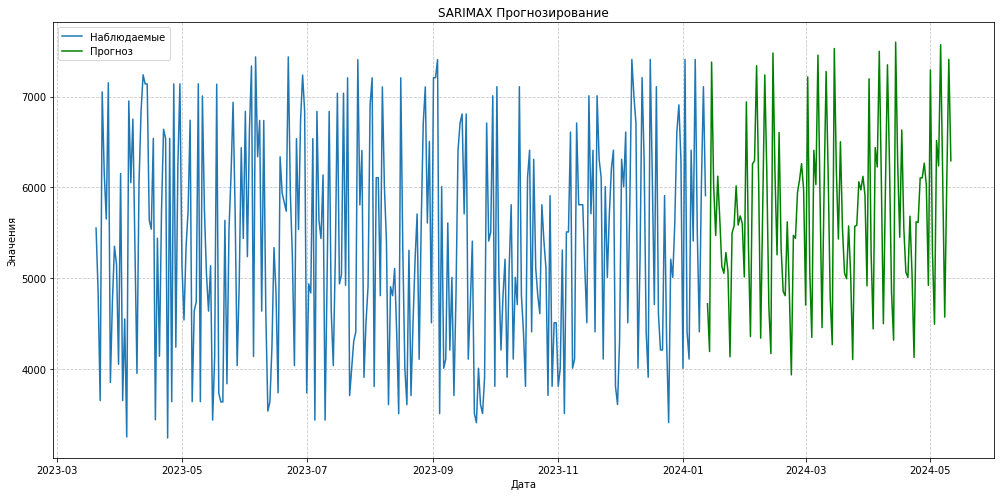

(<statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper at 0x1d65b561430>,
 Дата отражения в учетной системе  2023-01-16  2023-01-18  2023-02-01  \
 ID основного средства                                                  
 38006040007123001                        0.0         0.0         0.0   
 38006040007123002                        0.0         0.0         0.0   
 38006040007123003                        0.0         0.0         0.0   
 38006040007123004                        0.0         0.0         0.0   
 38006040007123005                        0.0         0.0         0.0   
 ...                                      ...         ...         ...   
 550060400331517610                       0.0         0.0         0.0   
 550060400331517611                       0.0         0.0         0.0   
 550060400331517612                       0.0         0.0         0.0   
 550060400331517613                       0.0         0.0         0.0   
 550060400331517614                       0.0 

In [186]:
make_predict_timeseries(preds, check_ID=55006040032948470, forecast_period=120)